# Project 03: Gibbs Sampling (Random Algorithm)

In [1]:
# Imports and Helper Functions
import random
import numpy as np
import bamnostic as bs
import seqlogo as sl
from IPython.display import Image, display

# Custom modules
from data_readers import *
from seq_ops import get_seq
from motif_ops import *

print("✅ Libraries and custom modules loaded.")

✅ Libraries and custom modules loaded.


In [2]:
# Utility Functions
def get_kmers(seq, k):
    """
    Generates all possible k-mers from a sequence, including the
    reverse complement to ensure the p53 motif is found on either strand.
    """
    kmer_seqs = []
    # reverse_complement must be available in your motif_ops or seq_ops modules
    seq_rev = reverse_complement(seq)

    # Iterate through the sequence to extract sliding windows of length k
    for ind in range(0, len(seq) - (k - 1)):
        kmer_seqs.append(seq[ind:ind + k])
        kmer_seqs.append(seq_rev[ind:ind + k])

    return kmer_seqs

def log2_weight_transform(scores):
    """
    Converts logarithmic PWM scores back into linear weights.
    This allows random.choices to pick sequences with a probability
    proportional to their fitness (2^score).
    """
    for ind, score in enumerate(scores):
        scores[ind] = 2 ** score

    return scores

print("✅ Utility functions successfully defined.")

✅ Utility functions successfully defined.


---
# Project Start
---

## Implement Gibbs Sampler


In [3]:
# Gibbs Motif Finder Logic
def GibbsMotifFinder(seqs, k, seed=None):
    '''
    Function to find a pfm from a list of strings using a Gibbs sampler

    Args:
        seqs (str list): a list of sequences, not necessarily in same lengths
        k (int): the length of motif to find
        seed (int, default=None): seed for np.random

    Returns:
        pfm (numpy array): dimensions are 4xlength
    '''
    # Define background noise to ignore
    monocharacter_seqs = {"A" * k, "C" * k, "T" * k, "G" * k}

    # Initialize random number generators
    random.seed(seed)
    rng = np.random.default_rng(seed)

    # Initial random motif for pfm
    motifs = []
    for seq in seqs:
        randint = random.randint(0, len(seq) - k)
        motifs.append(seq[randint:randint + k])

    print(f"Starting Gibbs Sampler on {len(seqs)} sequences...")
    print(f"Target Motif Length (k) = {k}")

    for _ in range(50000):
        rand_seq_ind = random.randint(0, len(seqs) - 1)
        rand_seq = seqs[rand_seq_ind]

        kmer_seqs = get_kmers(rand_seq, k)
        pfm = build_pfm(motifs, k)
        pwm = build_pwm(pfm)

        valid_kmers = []
        kmer_scores = []

        for kmer in kmer_seqs:
            if kmer in monocharacter_seqs:
                continue
            kmer_scores.append(score_kmer(kmer, pwm))
            valid_kmers.append(kmer)

        weights = log2_weight_transform(kmer_scores)
        new_motif = random.choices(valid_kmers, weights=weights)[0]
        motifs[rand_seq_ind] = new_motif

        if _ % 2000 == 0:
            print(len(kmer_seqs))
            print(f"Iteration {_} IC Score: {pfm_ic(pfm)}", end="\n" * 2)


    print(f"✅ Sampling Complete.")

    return pfm

## Setting up the data

In [4]:
#  Extracting Genomic Data

seq_file = "data/GCF_000009045.1_ASM904v1_genomic.fna"
gff_file = "data/GCF_000009045.1_ASM904v1_genomic.gff"

seqs = []
print(f"Reading genomic data from {seq_file}...")

for name, seq in get_fasta(seq_file):
    for gff_entry in get_gff(gff_file):
        # Filtering for Coding Sequences
        if gff_entry.type == 'CDS':
            # Extract 50bp promoter region based on strand orientation
            promoter_seq = get_seq(seq, gff_entry.start, gff_entry.end, gff_entry.strand, 50)

            # Filter for a specific Shine-Dalgarno-like consensus
            if "AGGAGG" in promoter_seq:
                seqs.append(promoter_seq)

print(f"✅ Extraction Complete: Found {len(seqs)} sequences containing 'AGGAGG'.")

Reading genomic data from data/GCF_000009045.1_ASM904v1_genomic.fna...
✅ Extraction Complete: Found 837 sequences containing 'AGGAGG'.


## Driver Program

In [5]:
# Running the Gibbs Sampler
promoter_pfm = GibbsMotifFinder(seqs, 10)
print("✅ SUCCESS: Motif Discovery Complete")
print("Final PFM:")
print(promoter_pfm)

Starting Gibbs Sampler on 837 sequences...
Target Motif Length (k) = 10
82
Iteration 0 IC Score: 0.7279449581834929

82
Iteration 2000 IC Score: 3.1795113214856503

82
Iteration 4000 IC Score: 6.395260804671714

82
Iteration 6000 IC Score: 10.96919602880399

82
Iteration 8000 IC Score: 12.440679971824942

82
Iteration 10000 IC Score: 12.602242192912769

82
Iteration 12000 IC Score: 12.6379316301297

82
Iteration 14000 IC Score: 12.650420812520847

82
Iteration 16000 IC Score: 12.661544610777876

82
Iteration 18000 IC Score: 12.650191785470883

82
Iteration 20000 IC Score: 12.650463225576928

82
Iteration 22000 IC Score: 12.653666283273852

82
Iteration 24000 IC Score: 12.649644211266816

82
Iteration 26000 IC Score: 12.640113821080813

82
Iteration 28000 IC Score: 12.655912724576266

82
Iteration 30000 IC Score: 12.661544610777876

82
Iteration 32000 IC Score: 12.661533668536077

82
Iteration 34000 IC Score: 12.660268850906526

82
Iteration 36000 IC Score: 12.655805210905033

82
Iterat

## Seqlogo

Rendering Sequence Logo...
✅ Visualization saved as 'promoter_motif.png'.


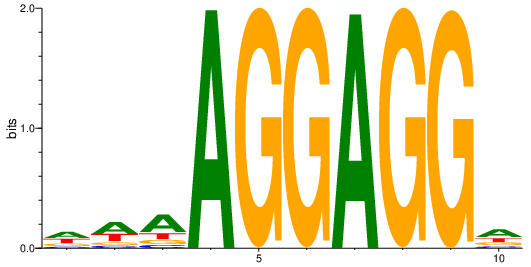

In [6]:
# Generating seqlogo
print("Rendering Sequence Logo...")

# Transpose the matrix 
pfm_data = promoter_pfm.T

# Normalization
pfm_data = promoter_pfm.T.astype(float)
row_sums = pfm_data.sum(axis=1, keepdims=True)
ppm_data = np.divide(pfm_data, row_sums, out=np.zeros_like(pfm_data), where=row_sums!=0)

# Generate the logo using the guaranteed normalized data
ppm = sl.Ppm(ppm_data)
sl.seqlogo(ppm, ic_scale=True, format='png', filename='promoter_motif.png')

# Display logo
print("✅ Visualization saved as 'promoter_motif.png'.")
display(Image('promoter_motif.png'))